In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
df = pd.read_csv("synthetic_sar_dataset.csv")

In [ ]:
# Drop non-useful columns
df = df.drop(columns=["customer_id"])  # ID not useful for prediction

In [ ]:
#Encode categorical colmuns
categorical_cols = [
    "kyc_risk_level",
    "customer_type",
    "occupation",
    "matched_typology"
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
#Separate features and target
X = df.drop(columns=["attention_required"])
y = df["attention_required"]

In [ ]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps class balance
)

In [ ]:
#Random forest model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

In [ ]:
#Train and predict
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[20  0]
 [ 0 20]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [ ]:
#Feature Importance
feature_importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:\n")
print(feature_importances)



Feature Importance:

total_outgoing_amount          0.158205
volume_spike_ratio             0.155000
matched_typology               0.138235
num_unique_senders             0.132564
num_incoming_transactions      0.129218
total_incoming_amount          0.125000
transaction_deviation_score    0.124876
structuring_flag               0.013732
rapid_fund_movement_flag       0.011595
foreign_transfer_flag          0.005934
layering_flag                  0.001967
mule_account_indicator         0.001908
past_alert_count               0.001765
kyc_risk_level                 0.000000
occupation                     0.000000
relationship_years             0.000000
customer_type                  0.000000
dtype: float64


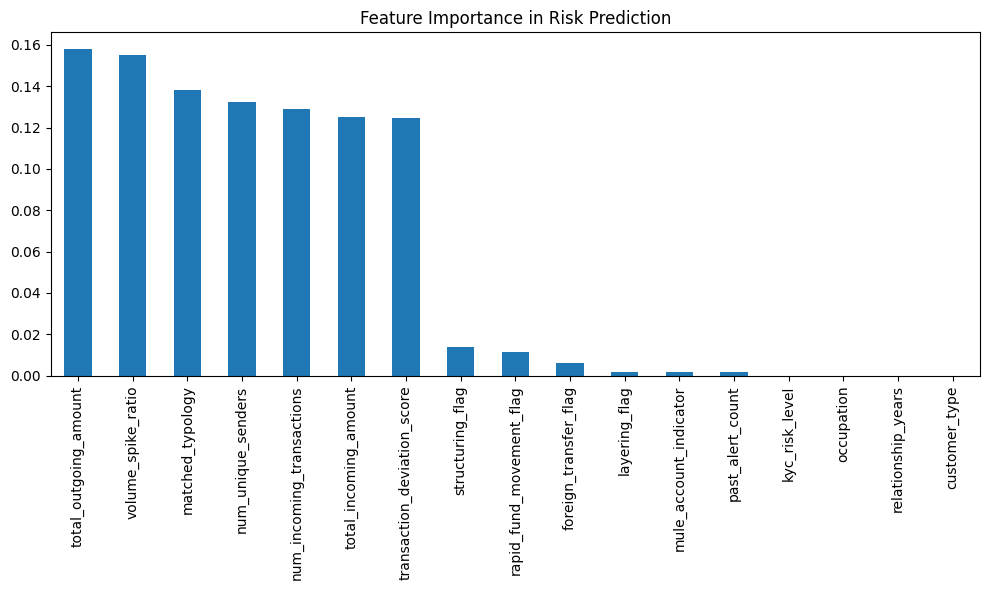

In [ ]:
# Plot feature importance
plt.figure(figsize=(10,6))
feature_importances.plot(kind='bar')
plt.title("Feature Importance in Risk Prediction")
plt.tight_layout()
plt.show()

In [ ]:
# Towards generating SAR promt
def generate_risk_signals(row):
    signals = []

    if row["foreign_transfer_flag"] == 1:
        signals.append("Foreign remittance detected")

    if row["structuring_flag"] == 1:
        signals.append("Structuring behavior identified")

    if row["layering_flag"] == 1:
        signals.append("Layering pattern observed")

    if row["mule_account_indicator"] == 1:
        signals.append("Potential mule account usage")

    if row["rapid_fund_movement_flag"] == 1:
        signals.append("Rapid movement of funds")

    if row["volume_spike_ratio"] > 2:
        signals.append("Unusual volume spike compared to historical behavior")

    if row["transaction_deviation_score"] > 2:
        signals.append("Significant deviation from customer’s normal activity")

    if row["past_alert_count"] > 1:
        signals.append("Multiple historical alerts")

    return signals


In [ ]:
#Create structured summary
def create_structured_summary(row, signals):

    summary = f"""
Subject Information:
- KYC Risk Level: {row['kyc_risk_level']}
- Customer Type: {row['customer_type']}
- Occupation: {row['occupation']}
- Relationship Duration: {row['relationship_years']} years

Activity Overview:
- Total Incoming Amount: ₹{row['total_incoming_amount']}
- Total Outgoing Amount: ₹{row['total_outgoing_amount']}
- Number of Incoming Transactions: {row['num_incoming_transactions']}
- Unique Senders: {row['num_unique_senders']}
- Foreign Transfer: {row['foreign_transfer_flag']}

Transaction Pattern Indicators:
{chr(10).join(["- " + s for s in signals])}

Historical Context:
- Past Alerts: {row['past_alert_count']}
- Deviation Score: {row['transaction_deviation_score']}
"""

    return summary


In [ ]:
#Promt generation for LLM
def generate_sar_prompt(structured_summary):

    prompt = f"""
You are a senior AML compliance analyst.

Based on the structured alert details below, generate a formal Suspicious Activity Report (SAR).

The SAR must include:

1. Clear narrative of what occurred
2. Timeline summary
3. Transaction behavior analysis
4. Justification for suspicion
5. Reference to AML typology
6. Risk conclusion

Alert Details:
{structured_summary}

Write in professional regulatory language suitable for submission to financial intelligence authorities.
"""

    return prompt


In [ ]:
# Connecting everything: ML → structured summary → (optional) LangChain → final SAR
predictions = model.predict(X_test)
sar_outputs = []

for i in range(len(predictions)):
    row = X_test.iloc[i]
    if predictions[i] == 1:
        signals = generate_risk_signals(row)
        structured_summary = create_structured_summary(row, signals)
        sar_outputs.append({
            "customer_index": X_test.index[i],
            "sar_summary": structured_summary
        })

# Optional: send each structured summary to LangChain (backend API) to get full SAR document
# Uncomment and set BACKEND_URL if your ProtoMind backend is running (e.g. http://localhost:4000)
# import requests
# BACKEND_URL = "http://localhost:4000"
# for sar in sar_outputs:
#     resp = requests.post(f"{BACKEND_URL}/sar/generate-from-summary", json={"summary": sar["sar_summary"]})
#     sar["final_sar_document"] = resp.json()["narrative"]

# Print how many SARs were generated
print(f"\nTotal SARs Generated: {len(sar_outputs)}")
for sar in sar_outputs[:2]:
    print("\n-------------------------------")
    print(f"Customer Index: {sar['customer_index']}")
    print(sar["sar_summary"])





Total SARs Generated: 20

-------------------------------
Customer Index: 82

Subject Information:
- KYC Risk Level: 1.0
- Customer Type: 1.0
- Occupation: 1.0
- Relationship Duration: 7.0 years

Activity Overview:
- Total Incoming Amount: ₹4679275.0
- Total Outgoing Amount: ₹4497205.0
- Number of Incoming Transactions: 54.0
- Unique Senders: 33.0
- Foreign Transfer: 1.0

Transaction Pattern Indicators:
- Foreign remittance detected
- Structuring behavior identified
- Layering pattern observed
- Rapid movement of funds
- Unusual volume spike compared to historical behavior
- Significant deviation from customer’s normal activity
- Multiple historical alerts

Historical Context:
- Past Alerts: 2.0
- Deviation Score: 3.15


-------------------------------
Customer Index: 191

Subject Information:
- KYC Risk Level: 1.0
- Customer Type: 1.0
- Occupation: 0.0
- Relationship Duration: 8.0 years

Activity Overview:
- Total Incoming Amount: ₹1044761.0
- Total Outgoing Amount: ₹988247.0
- Numbe

## Pipeline: Detection → Explainability → Narrative (LangChain)

- **Detection (ML):** `model.predict()` flags high-risk customers.
- **Explainability:** `generate_risk_signals()` + `create_structured_summary()` produce clean text (Subject Info, Activity Overview, Transaction Indicators, Historical Context). This is the right input for an LLM.
- **Narrative (LangChain):** Pass `sar["sar_summary"]` to the backend: `POST /sar/generate-from-summary` with `{"summary": "..."}`. The backend returns full SAR document text. To load data into the DB and UI, run from repo root: `npm run seed:synthetic`. This clears demo data, loads `synthetic_sar_dataset.csv`, creates Cases and SAR reports for all rows with `attention_required=1`, and generates SAR narratives via LangChain.